적용된 폰트: NanumGothic


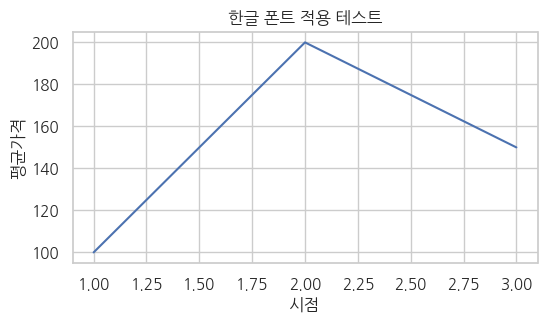

In [1]:
# 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = r"C:\Dev\fonts\NanumGothic-Regular.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# seaborn 스타일과 matplotlib 폰트를 한 번에 고정
sns.set_theme(style="whitegrid", rc={"font.family": font_name, "axes.unicode_minus": False})
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

# 폰트 설정 테스트
plt.figure(figsize=(6,3))

plt.title("한글 폰트 적용 테스트")
plt.xlabel("시점")
plt.ylabel("평균가격")

plt.plot([1,2,3],[100,200,150])

plt.show()

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 전처리 (예시: 배추)
train = pd.read_csv('./Data/train/train.csv')
supply = pd.read_csv('./Data/train/meta/TRAIN_산지공판장_2018-2021.csv', encoding='utf-8-sig')

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 타겟 10개 품목 리스트 정의 (사과는 홍로/후지가 섞여 있으니 품목명으로 일단 묶음)
target_items = [
    {'품목명': '건고추', '품종명': '화건', '거래단위': '30 kg', '등급': '상품'},
    {'품목명': '사과', '품종명': '후지', '거래단위': '10 개', '등급': '상품'}, # 후지도 별도 또는 병합 처리 필요
    {'품목명': '감자', '품종명': '감자 수미', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '배', '품종명': '신고', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '깐마늘(국산)', '품종명': '깐마늘(국산)', '거래단위': '20 kg', '등급': '상품'},
    {'품목명': '무', '품종명': '무', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '상추', '품종명': '청', '거래단위': '100 g', '등급': '상품'},
    {'품목명': '배추', '품종명': '배추', '거래단위': '10키로망대', '등급': '상'},
    {'품목명': '양파', '품종명': '양파', '거래단위': '1키로', '등급': '상'},
    {'품목명': '대파', '품종명': '대파(일반)', '거래단위': '1키로단', '등급': '상'}
]

# 2. 전체 시점(201801상순 ~ 202112하순) 생성 (144개 시점)
# 이 뼈대가 있어야 결측치가 있는 곳을 NaN으로 인식시킬 수 있습니다.
all_time_steps = train['시점'].unique()
all_time_df = pd.DataFrame({'시점': all_time_steps}).sort_values('시점')

imputed_results = {}

for item in target_items:
    name = item['품목명']

    # 3. 해당 품목 필터링
    # 사과의 경우 홍로/후지가 계절별로 교대되므로, 두 품종을 합쳐서 하나의 '사과' 시계열로 만드는 작업이 추가로 필요할 수 있습니다.
    cond = (train['품목명'] == item['품목명']) & \
           (train['품종명'] == item['품종명']) & \
           (train['거래단위'] == item['거래단위']) & \
           (train['등급'] == item['등급'])

    df_item = train[cond][['시점', '평균가격(원)']]

    # 총반입량 데이터 병합 (산지공판장 데이터 활용)
    # (여기서는 반입량 코드는 생략, 이전에 만든 df_supply 병합 로직 사용)

    # 4. 전체 시점 뼈대에 병합 (비어있는 시점은 NaN이 됨)
    df_merged = pd.merge(all_time_df, df_item, on='시점', how='left')

    # 5. 상태 공간 모델(칼만 필터) 적용
    # exog(반입량)이 결측치인 경우 0이나 평균으로 1차 채운 뒤 돌려야 합니다.
    model = sm.tsa.UnobservedComponents(
        df_merged['평균가격(원)'],
        level='local linear trend',
        seasonal=36,
        autoregressive=1
        # exog=df_merged['총반입량(kg)'] # 반입량 병합 시 추가
    )

    # 학습 (결측치가 있어도 알아서 학습함)
    res = model.fit(disp=False)

    # 6. 칼만 스무딩 결과로 결측치 채우기 (대박 기능!)
    # res.predict()를 하면 144개 시점의 '예측된 추세+계절성' 라인이 나옵니다.
    smoothed_prices = res.predict()

    # 실제 가격이 NaN인 곳만 스무딩된 예측값으로 쏙쏙 채워 넣음
    df_merged['대치가격(원)'] = df_merged['평균가격(원)'].fillna(smoothed_prices)

    imputed_results[name] = df_merged

print("10개 품목 칼만 필터 대치 완료!")

10개 품목 칼만 필터 대치 완료!


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 데이터 로드
train = pd.read_csv('train.csv')
wholesale = pd.read_csv('TRAIN_전국도매_2018-2021.csv')

# 2. 사과 '후지'로 수정한 10대 타겟 품목
target_items = [
    {'품목명': '건고추', '품종명': '화건', '거래단위': '30 kg', '등급': '상품'},
    {'품목명': '사과', '품종명': '후지', '거래단위': '10 개', '등급': '상품'}, # 홍로 -> 후지로 변경
    {'품목명': '감자', '품종명': '감자 수미', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '배', '품종명': '신고', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '깐마늘(국산)', '품종명': '깐마늘(국산)', '거래단위': '20 kg', '등급': '상품'},
    {'품목명': '무', '품종명': '무', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '상추', '품종명': '청', '거래단위': '100 g', '등급': '상품'},
    {'품목명': '배추', '품종명': '배추', '거래단위': '10키로망대', '등급': '상'},
    {'품목명': '양파', '품종명': '양파', '거래단위': '1키로', '등급': '상'},
    {'품목명': '대파', '품종명': '대파(일반)', '거래단위': '1키로단', '등급': '상'}
]

# 전체 144개 시점 뼈대 만들기
all_time_steps = train['시점'].unique()
all_time_df = pd.DataFrame({'시점': all_time_steps}).sort_values('시점')

imputed_results = {}

for item in target_items:
    name = f"{item['품목명']}_{item['품종명']}"

    # ----------------------------------------------------
    # [Step 1] 가격 데이터(y_t) 추출
    # ----------------------------------------------------
    cond_price = (train['품목명'] == item['품목명']) & \
                 (train['품종명'] == item['품종명']) & \
                 (train['거래단위'] == item['거래단위']) & \
                 (train['등급'] == item['등급'])
    df_price = train[cond_price][['시점', '평균가격(원)']]

    # ----------------------------------------------------
    # [Step 2] 전국도매 총반입량 데이터(x_t) 추출 및 집계
    # ----------------------------------------------------
    cond_supply = (wholesale['품목명'] == item['품목명']) & \
                  (wholesale['품종명'] == item['품종명'])
    df_supply = wholesale[cond_supply].groupby('시점')['총반입량(kg)'].sum().reset_index()

    # ----------------------------------------------------
    # [Step 3] 전체 시점 뼈대에 병합
    # ----------------------------------------------------
    df_merged = pd.merge(all_time_df, df_price, on='시점', how='left')
    df_merged = pd.merge(df_merged, df_supply, on='시점', how='left')

    # 🚨 중요: 가격(endog)은 결측치여도 칼만이 알아서 채워주지만,
    # 외생변수(exog)는 결측치가 있으면 에러가 납니다. 반입량이 없는 구간은 0으로 채웁니다.
    df_merged['총반입량(kg)'] = df_merged['총반입량(kg)'].fillna(0)

    # 안전장치
    valid_count = df_merged['평균가격(원)'].notna().sum()
    if valid_count == 0:
        print(f"[{name}] 데이터 0건. 건너뜁니다.")
        continue

    # ----------------------------------------------------
    # [Step 4] 상태 공간 모델 적용 (우리의 수식 구현!)
    # ----------------------------------------------------
    try:
        model = sm.tsa.UnobservedComponents(
            endog=df_merged['평균가격(원)'],      # y_t
            level='local linear trend',         # 추세 (수준 + 기울기)
            seasonal=36,                        # 계절성 (Rotate 36순)
            autoregressive=1,                   # 잔차 전이 (AR 1)
            exog=df_merged['총반입량(kg)']       # 외부충격 (총반입량 베타 계수)
        )

        # MLE로 파라미터(분산, 베타, 파이 등) 학습
        res = model.fit(disp=False)

        # 칼만 스무딩으로 144개 전체 시점 예측
        smoothed_prices = res.predict()

        # 원래 가격이 비어있던(NaN) 곳만 스무딩 결과로 채워 넣기
        df_merged['대치가격(원)'] = df_merged['평균가격(원)'].fillna(smoothed_prices)

        # 결과 딕셔너리에 저장
        imputed_results[name] = df_merged

        print(f"[{name}] 칼만 대치 완료! (원본 {valid_count}건 -> 144건 복원)")

    except Exception as e:
        print(f"[{name}] 에러 발생: {e}")

print("✅ 모든 품목의 상태 공간 모델 결측치 대치가 완료되었습니다!")

[건고추_화건] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[사과_후지] 칼만 대치 완료! (원본 125건 -> 144건 복원)
[감자_감자 수미] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[배_신고] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[깐마늘(국산)_깐마늘(국산)] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[무_무] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[상추_청] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[배추_배추] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[양파_양파] 칼만 대치 완료! (원본 144건 -> 144건 복원)
[대파_대파(일반)] 칼만 대치 완료! (원본 144건 -> 144건 복원)
✅ 모든 품목의 상태 공간 모델 결측치 대치가 완료되었습니다!


In [ ]:
# ----------------------------------------------------
# [Step 5] 대치된 결과를 하나의 데이터프레임으로 병합 및 CSV 추출
# ----------------------------------------------------

final_dfs = []

# 딕셔너리에 저장된 10개 품목의 데이터프레임을 순회하며 합치기
for name, df in imputed_results.items():
    # name은 '건고추_화건' 형태이므로 '_'를 기준으로 분리
    item_name, item_kind = name.split('_')

    # 데이터프레임에 품목/품종 정보 추가 (나중에 보기 편하게)
    df_clean = df.copy()
    df_clean.insert(0, '품목명', item_name)
    df_clean.insert(1, '품종명', item_kind)

    # 리스트에 담기
    final_dfs.append(df_clean)

# 리스트에 있는 10개의 데이터프레임을 세로로 길게 하나로 합치기
final_imputed_data = pd.concat(final_dfs, ignore_index=True)

# 우리가 필요한 핵심 컬럼만 순서대로 정렬
final_imputed_data = final_imputed_data[['시점', '품목명', '품종명', '총반입량(kg)', '평균가격(원)', '대치가격(원)']]

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
output_filename = 'train_imputed_kalman.csv'
final_imputed_data.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"🎉 모든 결측치 대치가 완료된 데이터가 '{output_filename}' 파일로 저장되었습니다!")

# 데이터가 잘 들어갔는지 상위 5개 확인
print(final_imputed_data.head())

🎉 모든 결측치 대치가 완료된 데이터가 'train_imputed_kalman.csv' 파일로 저장되었습니다!
         시점  품목명 품종명  총반입량(kg)   평균가격(원)   대치가격(원)
0  201801상순  건고추  화건       0.0  590000.0  590000.0
1  201801중순  건고추  화건       0.0  590000.0  590000.0
2  201801하순  건고추  화건       0.0  590000.0  590000.0
3  201802상순  건고추  화건       0.0  590000.0  590000.0
4  201802중순  건고추  화건       0.0  590000.0  590000.0


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 데이터 로드
train = pd.read_csv('train.csv')
wholesale_train = pd.read_csv('TRAIN_전국도매_2018-2021.csv')

test = pd.read_csv('TEST_00.csv')
wholesale_test = pd.read_csv('TEST_전국도매_00.csv')

# 2. 타겟 10대 품목
target_items = [
    {'품목명': '건고추', '품종명': '화건', '거래단위': '30 kg', '등급': '상품'},
    {'품목명': '사과', '품종명': '후지', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '감자', '품종명': '감자 수미', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '배', '품종명': '신고', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '깐마늘(국산)', '품종명': '깐마늘(국산)', '거래단위': '20 kg', '등급': '상품'},
    {'품목명': '무', '품종명': '무', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '상추', '품종명': '청', '거래단위': '100 g', '등급': '상품'},
    {'품목명': '배추', '품종명': '배추', '거래단위': '10키로망대', '등급': '상'},
    {'품목명': '양파', '품종명': '양파', '거래단위': '1키로', '등급': '상'},
    {'품목명': '대파', '품종명': '대파(일반)', '거래단위': '1키로단', '등급': '상'}
]

# 💡 [핵심] 도매시장 데이터용 이름표 매핑 (연료 주입을 위한 파이프 연결)
wholesale_name_map = {
    '깐마늘(국산)': '마늘',
    '건고추': '고추'
}

validation_results = []

for item in target_items:
    name = f"{item['품목명']}_{item['품종명']}"

    # --- [Step 1] 가격 데이터 추출 (기존과 동일하게 품종/단위/등급 모두 엄격히 매칭) ---
    cond_tr_p = (train['품목명'] == item['품목명']) & (train['품종명'] == item['품종명']) & \
                (train['거래단위'] == item['거래단위']) & (train['등급'] == item['등급'])
    df_tr_p = train[cond_tr_p][['시점', '평균가격(원)']]

    cond_te_p = (test['품목명'] == item['품목명']) & (test['품종명'] == item['품종명']) & \
                (test['거래단위'] == item['거래단위']) & (test['등급'] == item['등급'])
    df_te_p = test[cond_te_p][['시점', '평균가격(원)']]

    # 테스트셋에 해당 품목이나 'T' 시점 데이터가 없으면 패스 (IndexError 방지)
    if df_te_p.empty or df_te_p[df_te_p['시점'] == 'T'].empty:
        print(f"[{name}] Test 'T' 시점 데이터 부재. 건너뜁니다.")
        continue

    actual_price = df_te_p[df_te_p['시점'] == 'T']['평균가격(원)'].values[0]
    df_te_p.loc[df_te_p['시점'] == 'T', '평균가격(원)'] = np.nan # T시점 블라인드 처리

    # --- [Step 2] 반입량 데이터 추출 (💡 품종 무시! 오직 '품목명' 전체 합산) ---
    search_name = wholesale_name_map.get(item['품목명'], item['품목명'])

    # 도매시장 Train 반입량 합산
    cond_tr_s = (wholesale_train['품목명'] == search_name)
    df_tr_s = wholesale_train[cond_tr_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

    # 도매시장 Test 반입량 합산
    cond_te_s = (wholesale_test['품목명'] == search_name)
    df_te_s = wholesale_test[cond_te_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

    # --- [Step 3] 데이터 위아래 병합 및 결측치 0 처리 ---
    df_p = pd.concat([df_tr_p, df_te_p], ignore_index=True)
    df_s = pd.concat([df_tr_s, df_te_s], ignore_index=True)

    df_merged = pd.merge(df_p, df_s, on='시점', how='left')
    df_merged['총반입량(kg)'] = df_merged['총반입량(kg)'].fillna(0)

    # --- [Step 4] 상태 공간 모델 학습 및 예측 ---
    try:
        model = sm.tsa.UnobservedComponents(
            endog=df_merged['평균가격(원)'],
            level='local linear trend',
            seasonal=36,
            autoregressive=1,
            exog=df_merged['총반입량(kg)'] # 이제 모든 품종이 합산된 '진짜 연료'가 들어갑니다!
        )
        res = model.fit(disp=False)

        # 스무딩 및 T 시점(마지막 행) 예측값 추출
        smoothed_prices = res.predict()
        predicted_price = smoothed_prices.iloc[-1]

        error_rate = abs(predicted_price - actual_price) / actual_price * 100 if actual_price != 0 else 0

        validation_results.append({
            '품목': name,
            '실제_가격(T)': round(actual_price, 2),
            '예측_가격(T)': round(predicted_price, 2),
            '오차율(%)': round(error_rate, 2)
        })
        print(f"[{name}] 예측 완료! (오차율: {error_rate:.2f}%)")

    except Exception as e:
        print(f"[{name}] 모델 에러: {e}")

# --- [Step 5] 성적표 출력 ---
if validation_results:
    result_df = pd.DataFrame(validation_results)
    print("\n========== 🚀 대통합 공급량 기반 SSM 예측 성적표 ==========")
    print(result_df)
    print(f"\n💡 전체 품목 평균 예측 오차율(MAPE): {result_df['오차율(%)'].mean():.2f}%")

[건고추_화건] 예측 완료! (오차율: 7.13%)
[사과_후지] Test 'T' 시점 데이터 부재. 건너뜁니다.
[감자_감자 수미] 예측 완료! (오차율: 9.84%)
[배_신고] 예측 완료! (오차율: 17.42%)
[깐마늘(국산)_깐마늘(국산)] 예측 완료! (오차율: 0.56%)
[무_무] 예측 완료! (오차율: 2.21%)
[상추_청] 예측 완료! (오차율: 28.85%)
[배추_배추] 예측 완료! (오차율: 54.19%)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[양파_양파] 예측 완료! (오차율: 10.37%)
[대파_대파(일반)] 예측 완료! (오차율: 12.44%)

========== 🚀 대통합 공급량 기반 SSM 예측 성적표 ==========
                품목   실제_가격(T)   예측_가격(T)  오차율(%)
0           건고추_화건  673700.00  721723.93    7.13
1         감자_감자 수미   37901.38   41631.36    9.84
2             배_신고   30762.00   36119.93   17.42
3  깐마늘(국산)_깐마늘(국산)  168000.00  168932.80    0.56
4              무_무   34129.25   33375.07    2.21
5             상추_청    1213.00    1562.90   28.85
6            배추_배추   17092.50   26355.68   54.19
7            양파_양파    1513.38    1356.45   10.37
8        대파_대파(일반)    2097.38    1836.53   12.44

💡 전체 품목 평균 예측 오차율(MAPE): 15.89%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

# 모델 학습 시 발생하는 경고 메시지를 숨겨서 출력을 깔끔하게 만듭니다.
warnings.filterwarnings('ignore')

# 1. 공통 데이터 및 제출 양식 로드
train = pd.read_csv('train.csv')
wholesale_train = pd.read_csv('TRAIN_전국도매_2018-2021.csv')
submission = pd.read_csv('sample_submission.csv')

# 2. 타겟 10대 품목 및 도매시장 매핑 (작성하신 내용과 동일)
target_items = [
    {'품목명': '건고추', '품종명': '화건', '거래단위': '30 kg', '등급': '상품'},
    {'품목명': '사과', '품종명': '후지', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '감자', '품종명': '감자 수미', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '배', '품종명': '신고', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '깐마늘(국산)', '품종명': '깐마늘(국산)', '거래단위': '20 kg', '등급': '상품'},
    {'품목명': '무', '품종명': '무', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '상추', '품종명': '청', '거래단위': '100 g', '등급': '상품'},
    {'품목명': '배추', '품종명': '배추', '거래단위': '10키로망대', '등급': '상'},
    {'품목명': '양파', '품종명': '양파', '거래단위': '1키로', '등급': '상'},
    {'품목명': '대파', '품종명': '대파(일반)', '거래단위': '1키로단', '등급': '상'}
]

wholesale_name_map = {
    '깐마늘(국산)': '마늘',
    '건고추': '고추'
}

# 3. 제출 양식에서 평가해야 할 TEST ID 목록 추출 (예: 'TEST_00', 'TEST_01', ...)
test_ids = submission['시점'].apply(lambda x: x.split('+')[0]).unique()

# 결과를 채워넣기 편하도록 '시점'을 인덱스로 설정합니다.
result_sub = submission.copy()
result_sub.set_index('시점', inplace=True)

print(f"총 {len(test_ids)}개의 테스트 데이터셋에 대한 예측을 시작합니다...\n")

# 4. 각 테스트 데이터셋별로 반복 처리
for test_id in test_ids:
    print(f"[{test_id}] 예측 진행 중...")

    # 해당 번호의 테스트 데이터 및 도매 데이터 로드
    # 예: test_id가 'TEST_00'이면 'TEST_00.csv' 와 'TEST_전국도매_00.csv'를 로드
    test_num = test_id.split('_')[1] # '00', '01' 등 추출

    try:
        test = pd.read_csv(f'{test_id}.csv')
        wholesale_test = pd.read_csv(f'TEST_전국도매_{test_num}.csv')
    except FileNotFoundError:
        print(f"  [경고] {test_id} 관련 파일을 찾을 수 없어 건너뜁니다.")
        continue

    # 5. 각 품목별로 모델 학습 및 3-step 예측
    for item in target_items:
        # 제출 파일의 컬럼명은 품목명과 동일합니다. (예: '사과', '배추')
        col_name = item['품목명']

        # --- [Step 5-1] 가격 데이터 추출 (Train + Test) ---
        cond_tr_p = (train['품목명'] == item['품목명']) & (train['품종명'] == item['품종명']) & \
                    (train['거래단위'] == item['거래단위']) & (train['등급'] == item['등급'])
        df_tr_p = train[cond_tr_p][['시점', '평균가격(원)']]

        cond_te_p = (test['품목명'] == item['품목명']) & (test['품종명'] == item['품종명']) & \
                    (test['거래단위'] == item['거래단위']) & (test['등급'] == item['등급'])
        df_te_p = test[cond_te_p][['시점', '평균가격(원)']]

        df_p = pd.concat([df_tr_p, df_te_p], ignore_index=True)

        # --- [Step 5-2] 반입량 데이터 추출 및 합산 ---
        search_name = wholesale_name_map.get(item['품목명'], item['품목명'])

        cond_tr_s = (wholesale_train['품목명'] == search_name)
        df_tr_s = wholesale_train[cond_tr_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

        cond_te_s = (wholesale_test['품목명'] == search_name)
        df_te_s = wholesale_test[cond_te_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

        df_s = pd.concat([df_tr_s, df_te_s], ignore_index=True)

        # --- [Step 5-3] 병합 및 결측치 처리 ---
        df_merged = pd.merge(df_p, df_s, on='시점', how='left')
        df_merged['총반입량(kg)'] = df_merged['총반입량(kg)'].fillna(0)
        # 가격 결측치는 SSM이 알아서 처리하므로 따로 fillna 하지 않습니다.

        # --- [Step 5-4] 미래 예측을 위한 외부 변수(Exog) 가정 ---
        # T+1, T+2, T+3 시점의 가격을 예측하려면 해당 시점의 '총반입량' 정보도 필요합니다.
        # 가장 단순하면서 합리적인 방법으로, "최근 3개 시점의 평균 반입량"이 미래 3번의 시점에도 유지된다고 가정합니다.
        recent_mean_supply = df_merged['총반입량(kg)'].tail(3).mean()
        future_exog = [recent_mean_supply, recent_mean_supply, recent_mean_supply]

        # --- [Step 5-5] 모델 학습 및 예측 ---
        try:
            model = sm.tsa.UnobservedComponents(
                endog=df_merged['평균가격(원)'],
                level='local linear trend',
                seasonal=36,
                autoregressive=1,
                exog=df_merged['총반입량(kg)']
            )
            res = model.fit(disp=False)

            # forecast() 함수를 사용하여 데이터 끝점에서 3스텝(T+1, T+2, T+3) 미래 예측
            forecasts = res.forecast(steps=3, exog=future_exog)

            # 음수 가격 방지 (가격이 0 미만이 될 수 없으므로)
            forecasts = np.maximum(forecasts, 0)

            # --- [Step 5-6] 예측값을 제출 양식 데이터프레임에 매핑 ---
            result_sub.loc[f'{test_id}+1순', col_name] = forecasts.iloc[0]
            result_sub.loc[f'{test_id}+2순', col_name] = forecasts.iloc[1]
            result_sub.loc[f'{test_id}+3순', col_name] = forecasts.iloc[2]

        except Exception as e:
            print(f"  [오류] {test_id} - {col_name} 예측 실패: {e}")
            # 에러 발생 시 베이스라인으로 0으로 채움 (대회 규정 및 상황에 맞게 변경 가능)
            result_sub.loc[f'{test_id}+1순', col_name] = 0
            result_sub.loc[f'{test_id}+2순', col_name] = 0
            result_sub.loc[f'{test_id}+3순', col_name] = 0

# 6. 인덱스를 다시 컬럼으로 빼고 최종 CSV 저장
result_sub.reset_index(inplace=True)
result_sub.to_csv('final_submission.csv', index=False)
print("\n🎉 모든 예측이 완료되었으며 'final_submission.csv' 파일이 성공적으로 저장되었습니다!")

총 25개의 테스트 데이터셋에 대한 예측을 시작합니다...

[TEST_00] 예측 진행 중...
[TEST_01] 예측 진행 중...
[TEST_02] 예측 진행 중...
[TEST_03] 예측 진행 중...
[TEST_04] 예측 진행 중...
[TEST_05] 예측 진행 중...
[TEST_06] 예측 진행 중...
[TEST_07] 예측 진행 중...
[TEST_08] 예측 진행 중...
[TEST_09] 예측 진행 중...
[TEST_10] 예측 진행 중...
[TEST_11] 예측 진행 중...
[TEST_12] 예측 진행 중...
[TEST_13] 예측 진행 중...
[TEST_14] 예측 진행 중...
[TEST_15] 예측 진행 중...
[TEST_16] 예측 진행 중...
[TEST_17] 예측 진행 중...
[TEST_18] 예측 진행 중...
[TEST_19] 예측 진행 중...
[TEST_20] 예측 진행 중...
[TEST_21] 예측 진행 중...
[TEST_22] 예측 진행 중...
[TEST_23] 예측 진행 중...
[TEST_24] 예측 진행 중...

🎉 모든 예측이 완료되었으며 'final_submission.csv' 파일이 성공적으로 저장되었습니다!


=== 🚀 품목별 잔차(순수 변동분) 기준 CCF 분석 ===



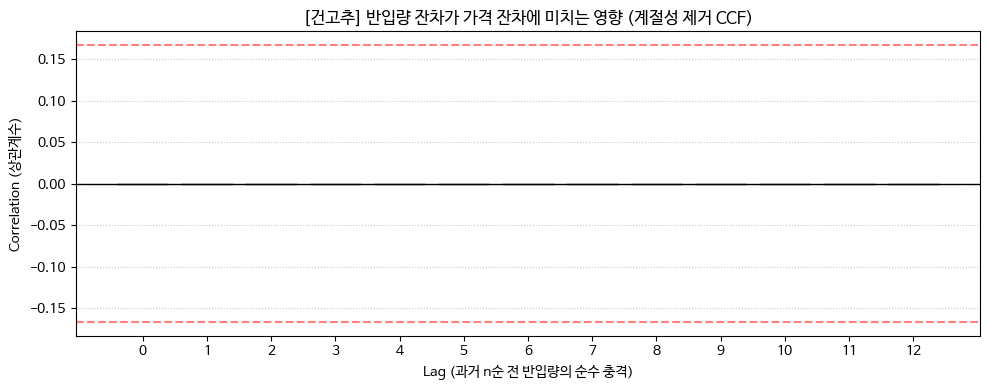

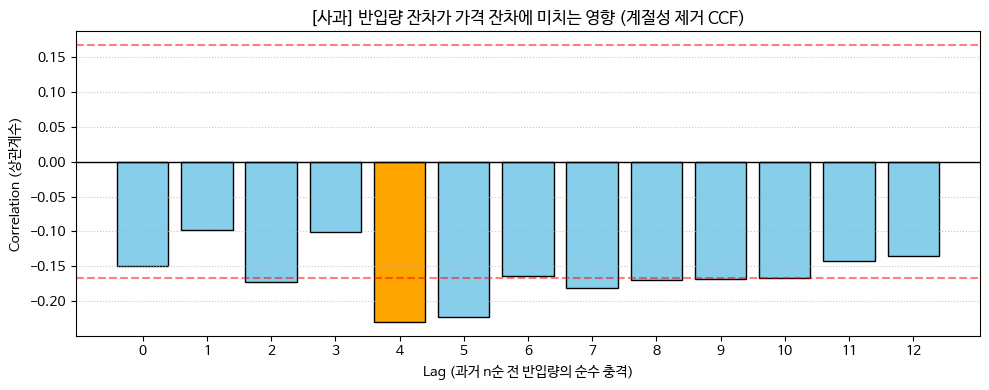

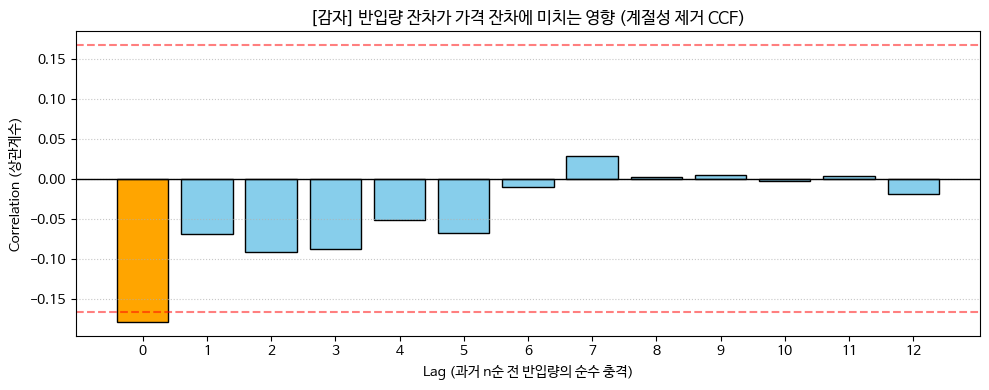

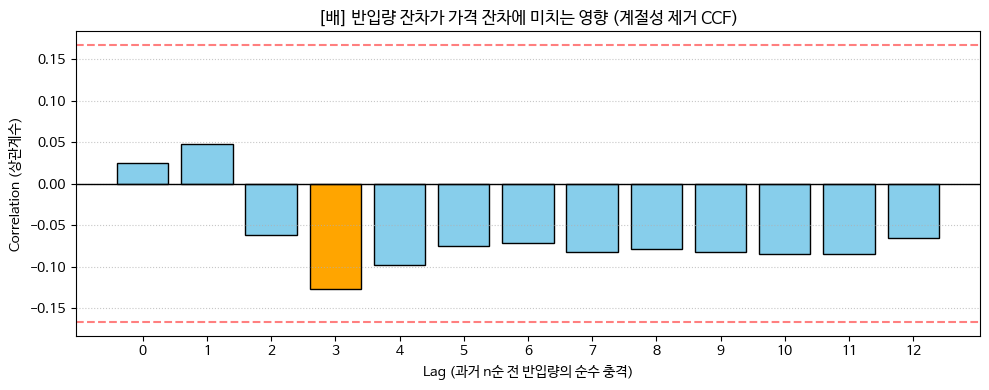

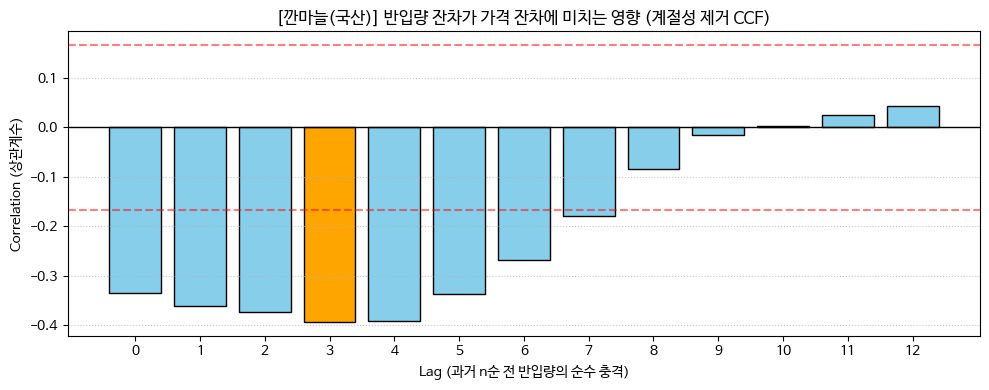

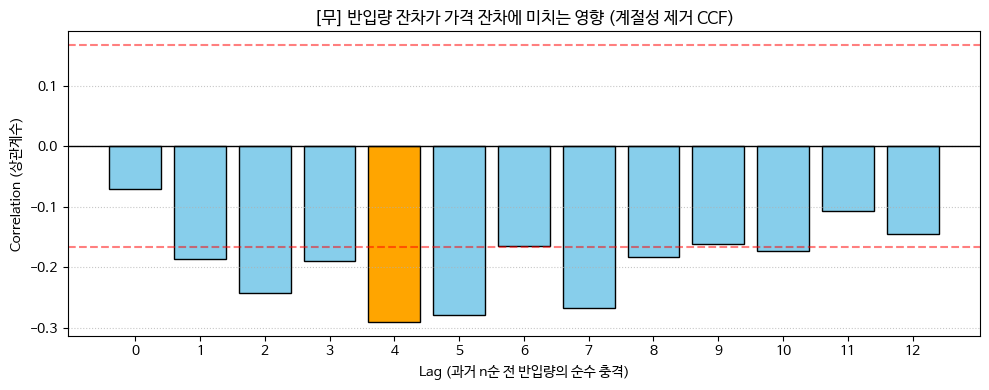

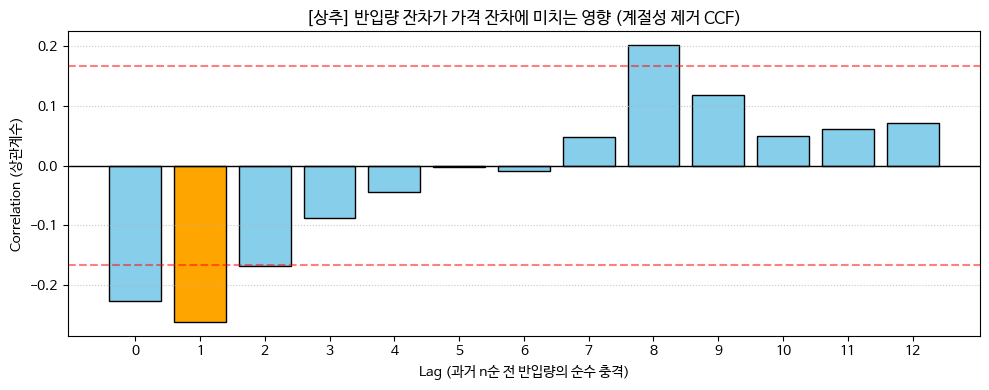

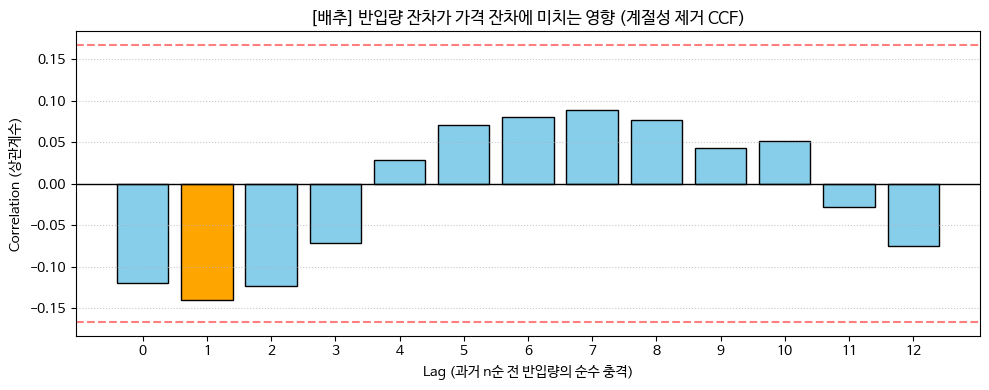

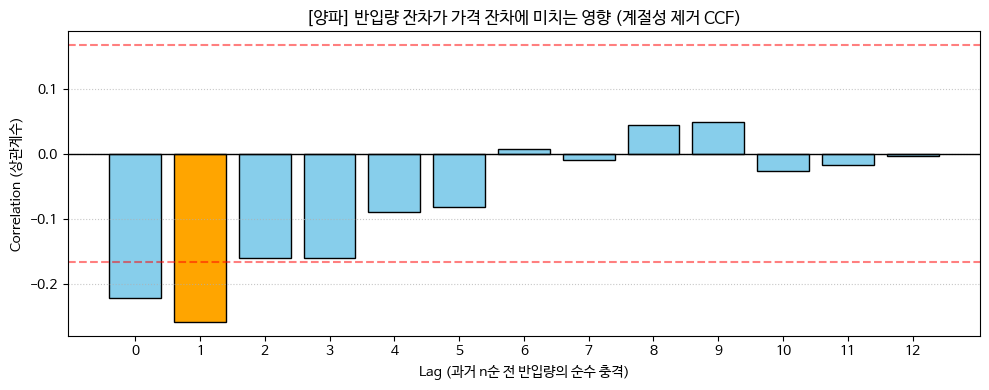

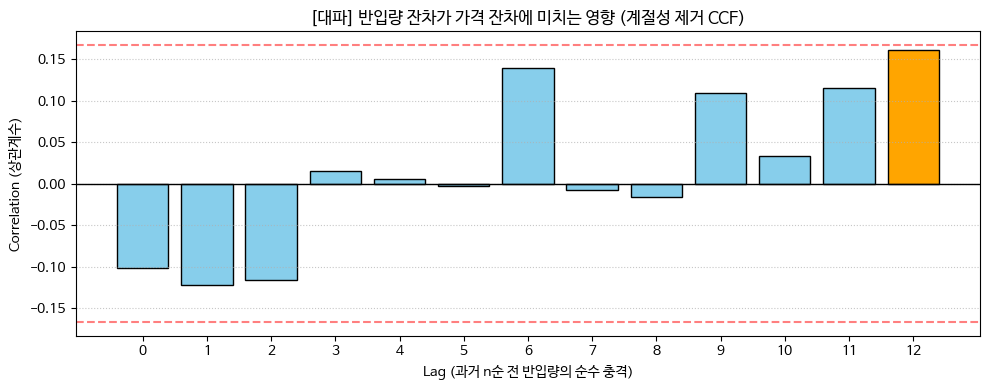

잔차 기반 CCF 분석이 완료되었습니다!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import warnings

# 경고 메시지 숨기기 및 한글 폰트 설정
warnings.filterwarnings('ignore')


# 1. 데이터 로드
train = pd.read_csv('train.csv')
wholesale = pd.read_csv('TRAIN_전국도매_2018-2021.csv')

# 2. 도매시장 조건 필터링
wholesale_filtered = wholesale[wholesale['시장명'] == '*전국도매시장']
wholesale_name_map = {'깐마늘(국산)': '마늘', '건고추': '고추'}

target_items = [
    '건고추', '사과', '감자', '배', '깐마늘(국산)',
    '무', '상추', '배추', '양파', '대파'
]

all_time_steps = train['시점'].unique()
all_time_df = pd.DataFrame({'시점': all_time_steps}).sort_values('시점')

print("=== 🚀 품목별 잔차(순수 변동분) 기준 CCF 분석 ===\n")

for item in target_items:

    # [Step 1] 데이터 병합
    cond_price = (train['품목명'] == item)
    df_price = train[cond_price].groupby('시점')['평균가격(원)'].sum().reset_index()

    search_name = wholesale_name_map.get(item, item)
    cond_supply = (wholesale_filtered['품목명'] == search_name)
    df_supply = wholesale_filtered[cond_supply].groupby('시점')['총반입량(kg)'].sum().reset_index()

    df_merged = pd.merge(all_time_df, df_price, on='시점', how='left')
    df_merged = pd.merge(df_merged, df_supply, on='시점', how='left')

    # 💡 [Step 2] 결측치 선형 보간 (STL은 NaN을 허용하지 않음)
    # 선형 보간 후, 앞뒤로 남은 빈칸은 가까운 값으로 채움
    df_merged['평균가격(원)'] = df_merged['평균가격(원)'].interpolate(method='linear').bfill().ffill()
    df_merged['총반입량(kg)'] = df_merged['총반입량(kg)'].interpolate(method='linear').bfill().ffill()

    # 💡 [Step 3] STL 기반 시계열 분해 (1년 = 36순)
    # robust=True를 주어 이상치(명절 급등 등)에 모델이 흔들리지 않게 합니다.
    try:
        stl_price = STL(df_merged['평균가격(원)'], period=36, robust=True).fit()
        stl_supply = STL(df_merged['총반입량(kg)'], period=36, robust=True).fit()

        # 잔차(Residual)만 추출
        resid_price = stl_price.resid
        resid_supply = stl_supply.resid

    except ValueError as e:
        print(f"[{item}] STL 분해 중 에러 발생 (데이터 부족 등): {e}")
        continue

    # [Step 4] 시차(Lag)별 상관계수 계산 (잔차 CCF)
    max_lag = 12
    lags = np.arange(0, max_lag + 1)
    ccf_values = []

    for lag in lags:
        # 과거 lag 시점의 '반입량 잔차'
        shifted_resid_supply = resid_supply.shift(lag)
        # 현재 시점의 '가격 잔차'와의 상관관계
        corr = shifted_resid_supply.corr(resid_price)
        ccf_values.append(corr)

    # [Step 5] 시각화
    plt.figure(figsize=(10, 4))

    ccf_values = np.nan_to_num(ccf_values)
    colors = ['orange' if abs(val) == max(np.abs(ccf_values)) else 'skyblue' for val in ccf_values]

    plt.bar(lags, ccf_values, color=colors, edgecolor='black')
    plt.axhline(0, color='black', linewidth=1)

    # 유의수준 임계선
    n = len(df_merged)
    threshold = 2 / np.sqrt(n)
    plt.axhline(threshold, color='red', linestyle='--', alpha=0.5)
    plt.axhline(-threshold, color='red', linestyle='--', alpha=0.5)

    plt.title(f'[{item}] 반입량 잔차가 가격 잔차에 미치는 영향 (계절성 제거 CCF)')
    plt.xlabel('Lag (과거 n순 전 반입량의 순수 충격)')
    plt.ylabel('Correlation (상관계수)')
    plt.xticks(lags)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()

    plt.show()

print("잔차 기반 CCF 분석이 완료되었습니다!")

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

# 모델 학습 시 발생하는 경고 메시지를 숨겨서 출력을 깔끔하게 만듭니다.
warnings.filterwarnings('ignore')

# 1. 공통 데이터 및 제출 양식 로드
train = pd.read_csv('train.csv')
wholesale_train = pd.read_csv('TRAIN_전국도매_2018-2021.csv')
submission = pd.read_csv('sample_submission.csv')

# 2. 타겟 10대 품목 및 도매시장 매핑
target_items = [
    {'품목명': '건고추', '품종명': '화건', '거래단위': '30 kg', '등급': '상품'},
    {'품목명': '사과', '품종명': '후지', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '감자', '품종명': '감자 수미', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '배', '품종명': '신고', '거래단위': '10 개', '등급': '상품'},
    {'품목명': '깐마늘(국산)', '품종명': '깐마늘(국산)', '거래단위': '20 kg', '등급': '상품'},
    {'품목명': '무', '품종명': '무', '거래단위': '20키로상자', '등급': '상'},
    {'품목명': '상추', '품종명': '청', '거래단위': '100 g', '등급': '상품'},
    {'품목명': '배추', '품종명': '배추', '거래단위': '10키로망대', '등급': '상'},
    {'품목명': '양파', '품종명': '양파', '거래단위': '1키로', '등급': '상'},
    {'품목명': '대파', '품종명': '대파(일반)', '거래단위': '1키로단', '등급': '상'}
]

wholesale_name_map = {
    '깐마늘(국산)': '마늘',
    '건고추': '고추'
}

# 💡 [추가] 품목별 분석된 시차(Lag) 딕셔너리
lag_dict = {
    '건고추': None, # 외생변수 제외
    '사과': 4,
    '감자': 2,
    '배': 3,
    '깐마늘(국산)': 3,
    '무': 4,
    '상추': 2,
    '배추': 2,
    '양파': 2,
    '대파': 2
}

test_ids = submission['시점'].apply(lambda x: x.split('+')[0]).unique()
result_sub = submission.copy()
result_sub.set_index('시점', inplace=True)

print(f"총 {len(test_ids)}개의 테스트 데이터셋 예측을 시작합니다 (맞춤 시차 적용)...\n")

# 4. 각 테스트 데이터셋별로 반복 처리
for test_id in test_ids:
    print(f"[{test_id}] 예측 진행 중...")
    test_num = test_id.split('_')[1]

    try:
        test = pd.read_csv(f'{test_id}.csv')
        wholesale_test = pd.read_csv(f'TEST_전국도매_{test_num}.csv')
    except FileNotFoundError:
        print(f"  [경고] {test_id} 관련 파일을 찾을 수 없어 건너뜁니다.")
        continue

    # 5. 각 품목별로 모델 학습 및 예측
    for item in target_items:
        col_name = item['품목명']
        lag_val = lag_dict[col_name]

        # --- [Step 5-1] 가격 데이터 추출 (Train + Test) ---
        cond_tr_p = (train['품목명'] == item['품목명']) & (train['품종명'] == item['품종명']) & \
                    (train['거래단위'] == item['거래단위']) & (train['등급'] == item['등급'])
        df_tr_p = train[cond_tr_p][['시점', '평균가격(원)']]

        cond_te_p = (test['품목명'] == item['품목명']) & (test['품종명'] == item['품종명']) & \
                    (test['거래단위'] == item['거래단위']) & (test['등급'] == item['등급'])
        df_te_p = test[cond_te_p][['시점', '평균가격(원)']]

        df_p = pd.concat([df_tr_p, df_te_p], ignore_index=True)

        # --- [Step 5-2] 반입량 데이터 추출 및 병합 ---
        search_name = wholesale_name_map.get(item['품목명'], item['품목명'])

        cond_tr_s = (wholesale_train['품목명'] == search_name)
        df_tr_s = wholesale_train[cond_tr_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

        cond_te_s = (wholesale_test['품목명'] == search_name)
        df_te_s = wholesale_test[cond_te_s].groupby('시점')['총반입량(kg)'].sum().reset_index()

        df_s = pd.concat([df_tr_s, df_te_s], ignore_index=True)

        df_merged = pd.merge(df_p, df_s, on='시점', how='left')
        df_merged['총반입량(kg)'] = df_merged['총반입량(kg)'].fillna(0)

        # --- [Step 5-3] 맞춤 시차(Lag) 적용 및 Exog 생성 ---
        if lag_val is None:
            # 건고추: 외생변수 없음
            exog_train = None
            exog_future = None
        else:
            # 💡 [핵심] 시차(Lag) 만큼 반입량을 뒤로 미루기 위한 작업
            # 혹시 모를 미래 예측 구간을 위해 임의로 3개의 평균값을 뒤에 붙여놓고 shift 적용
            recent_mean = df_merged['총반입량(kg)'].tail(3).mean()
            extended_supply = pd.concat([df_merged['총반입량(kg)'], pd.Series([recent_mean]*3)], ignore_index=True)

            # 지정된 래그(lag)만큼 반입량을 아래로 밀어냅니다. (빈칸은 가장 가까운 과거 값으로 채움)
            shifted_supply = extended_supply.shift(lag_val).fillna(method='bfill')

            # 모델 학습용 exog (원래 데이터 길이만큼)
            exog_train = shifted_supply.iloc[:len(df_merged)].values
            # T+1, T+2, T+3 예측용 exog (붙여놓았던 마지막 3개)
            exog_future = shifted_supply.iloc[len(df_merged):].values

        # --- [Step 5-4] 모델 학습 및 예측 ---
        try:
            # 동적으로 파라미터를 설정 (exog 유무에 따라 다름)
            model_params = {
                'endog': df_merged['평균가격(원)'],
                'level': 'local linear trend',
                'seasonal': 36,
                'autoregressive': 1
            }
            if exog_train is not None:
                model_params['exog'] = exog_train

            model = sm.tsa.UnobservedComponents(**model_params)
            res = model.fit(disp=False)

            # 미래 예측 (건고추는 exog 없이 예측)
            if exog_future is not None:
                forecasts = res.forecast(steps=3, exog=exog_future)
            else:
                forecasts = res.forecast(steps=3)

            forecasts = np.maximum(forecasts.values, 0) # 음수 방지

            # --- [Step 5-5] 결과 매핑 ---
            result_sub.loc[f'{test_id}+1순', col_name] = forecasts[0]
            result_sub.loc[f'{test_id}+2순', col_name] = forecasts[1]
            result_sub.loc[f'{test_id}+3순', col_name] = forecasts[2]

        except Exception as e:
            print(f"  [경고] {test_id} - {col_name} 예측 실패, 기본값 0 처리. ({e})")
            result_sub.loc[f'{test_id}+1순', col_name] = 0
            result_sub.loc[f'{test_id}+2순', col_name] = 0
            result_sub.loc[f'{test_id}+3순', col_name] = 0

# 6. 인덱스 복구 및 저장
result_sub.reset_index(inplace=True)
result_sub.to_csv('final_submission_lag_applied.csv', index=False)
print("\n🎉 모든 맞춤 시차 예측이 완료되어 'final_submission_lag_applied.csv'에 저장되었습니다!")

총 25개의 테스트 데이터셋 예측을 시작합니다 (맞춤 시차 적용)...

[TEST_00] 예측 진행 중...
[TEST_01] 예측 진행 중...
[TEST_02] 예측 진행 중...
[TEST_03] 예측 진행 중...
[TEST_04] 예측 진행 중...
[TEST_05] 예측 진행 중...
[TEST_06] 예측 진행 중...
[TEST_07] 예측 진행 중...
[TEST_08] 예측 진행 중...
[TEST_09] 예측 진행 중...
[TEST_10] 예측 진행 중...
[TEST_11] 예측 진행 중...
[TEST_12] 예측 진행 중...
[TEST_13] 예측 진행 중...
[TEST_14] 예측 진행 중...
[TEST_15] 예측 진행 중...
[TEST_16] 예측 진행 중...
[TEST_17] 예측 진행 중...
[TEST_18] 예측 진행 중...
[TEST_19] 예측 진행 중...
[TEST_20] 예측 진행 중...
[TEST_21] 예측 진행 중...
[TEST_22] 예측 진행 중...
[TEST_23] 예측 진행 중...
[TEST_24] 예측 진행 중...

🎉 모든 맞춤 시차 예측이 완료되어 'final_submission_lag_applied.csv'에 저장되었습니다!
